# 01 — Exploratory Data Analysis
*The Price of Lahore's Air — satellite reconstruction of PM2.5.*

This notebook inspects the merged daily model frame before any modeling:
ground-truth coverage, missingness of satellite inputs, the seasonal cycle,
and the AOD–PM2.5 relationship that the model will exploit.

**Ground truth honesty note:** Lahore has exactly one reference-grade public
monitor (US Consulate, via OpenAQ), covering May 2019 – Feb 2025 with ~21%
of days missing. 81 low-cost sensors (AirGradient/Clarity) exist from late
2023 onward; their daily median is kept as an *independent comparison series*,
never as a training target.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
FIG = '../figures'

df = pd.read_parquet('../data/processed/model_frame.parquet')
df['year'] = df.date.dt.year
print(df.shape)
df[['date','pm25','pm25_lcs_median','aod','no2','aer_ai','t2m','blh',
    'fires_east','fires_west']].describe().T.round(2)

(3106, 55)


,count,mean,min,25%,50%,75%,max,std
date,3106,2022-04-02 11:59:59.999999744,2018-01-01 00:00:00,2020-02-16 06:00:00,2022-04-02 12:00:00,2024-05-17 18:00:00,2026-07-03 00:00:00,NaN
pm25,1656.0,127.607603,0.2,53.75,87.95,178.0,630.0,101.694422
pm25_lcs_median,948.0,99.93731,12.05,43.2375,66.0,153.0,416.0,74.116613
aod,2598.0,0.9117,0.119294,0.561522,0.771407,1.138129,4.328545,0.508034
no2,2617.0,0.000085,0.00001,0.000055,0.000075,0.000102,0.000456,0.000047
aer_ai,2919.0,-0.183796,-2.454351,-0.814053,-0.205423,0.367335,3.949806,0.845806
t2m,3099.0,296.943962,279.50573,289.911256,298.690744,303.189676,311.11173,7.660155
blh,3101.0,454.236027,79.858693,263.308871,396.132684,571.515431,1544.422387,253.643194
fires_east,3106.0,141.18416,0.0,1.0,11.0,42.0,5278.0,453.587904
fires_west,3106.0,53.324211,0.0,4.0,19.0,57.0,796.0,91.940796


## 1. Ground-truth coverage — what we actually have

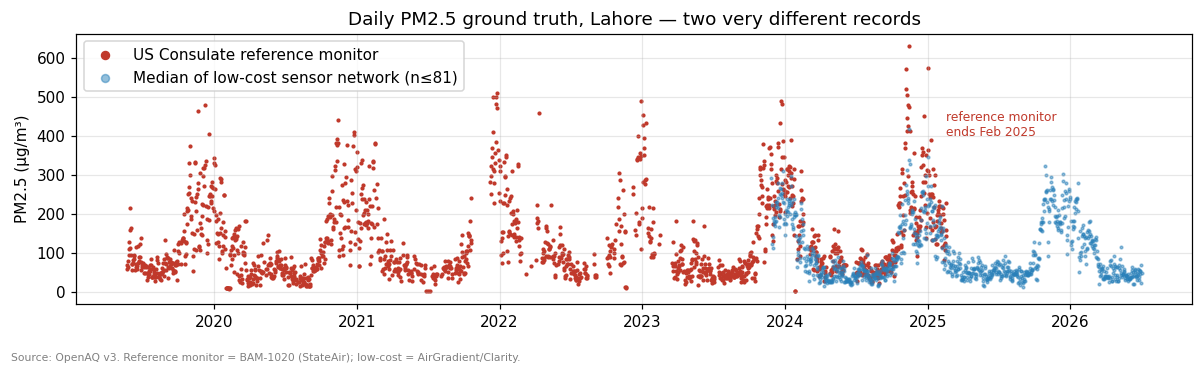

labeled days: 1656 (2019-05-23 → 2025-02-18)
overlap days (ref & low-cost median): 391, r = 0.927


In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.scatter(df.date, df.pm25, s=3, color='#c0392b', label='US Consulate reference monitor')
ax.scatter(df.date, df.pm25_lcs_median, s=3, color='#2980b9', alpha=.5,
           label='Median of low-cost sensor network (n≤81)')
ax.set(ylabel='PM2.5 (µg/m³)', title='Daily PM2.5 ground truth, Lahore — two very different records')
ax.legend(loc='upper left', markerscale=3)
ax.annotate('reference monitor\nends Feb 2025', xy=(pd.Timestamp('2025-02-18'), 400),
            fontsize=8, color='#c0392b')
fig.text(.01,-.04,'Source: OpenAQ v3. Reference monitor = BAM-1020 (StateAir); low-cost = AirGradient/Clarity.',
         fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/eda_ground_truth_coverage.png', bbox_inches='tight')
plt.show()

lab = df.pm25.notna()
print(f"labeled days: {lab.sum()} ({df.loc[lab,'date'].min():%Y-%m-%d} → {df.loc[lab,'date'].max():%Y-%m-%d})")
both = df.dropna(subset=['pm25','pm25_lcs_median'])
print(f"overlap days (ref & low-cost median): {len(both)}, r = {both.pm25.corr(both.pm25_lcs_median):.3f}")

The two records agree well where they overlap, which is what lets us use
the low-cost network median later as an *out-of-sample* sanity check for
reconstructed 2025–26 values (after the reference monitor went dark).

## 2. Missingness of satellite inputs

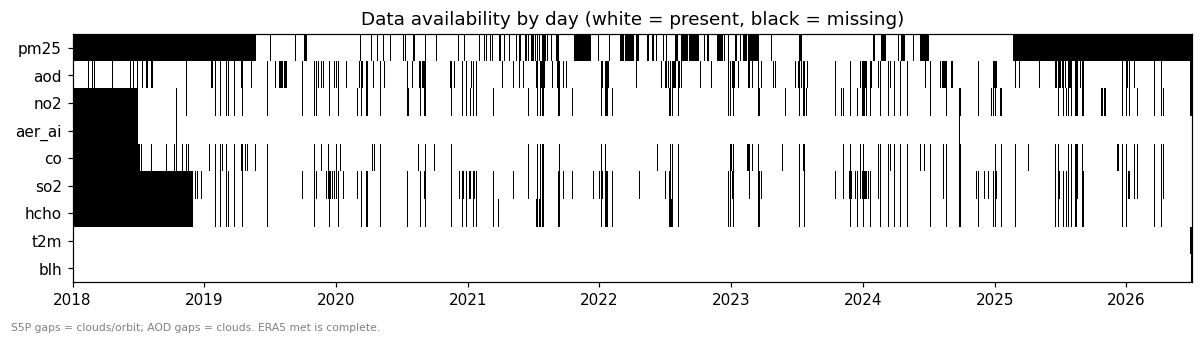

pm25      0.53
aod       0.84
no2       0.84
aer_ai    0.94
co        0.86
so2       0.78
hcho      0.82
t2m       1.00
blh       1.00


In [3]:
sat_cols = ['pm25','aod','no2','aer_ai','co','so2','hcho','t2m','blh']
miss = df.set_index('date')[sat_cols].notna().astype(int)
fig, ax = plt.subplots(figsize=(11, 3))
ax.imshow(miss.T.values, aspect='auto', cmap='Greys_r', interpolation='none',
          extent=[mdates.date2num(df.date.min()), mdates.date2num(df.date.max()), len(sat_cols)-.5, -.5])
ax.xaxis_date(); ax.set_yticks(range(len(sat_cols))); ax.set_yticklabels(sat_cols)
ax.set_title('Data availability by day (white = present, black = missing)')
ax.grid(False)
fig.text(.01,-.02,'S5P gaps = clouds/orbit; AOD gaps = clouds. ERA5 met is complete.', fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/eda_missingness.png', bbox_inches='tight'); plt.show()
print(df[sat_cols].notna().mean().round(2).to_string())

## 3. The seasonal cycle — Lahore's smog season

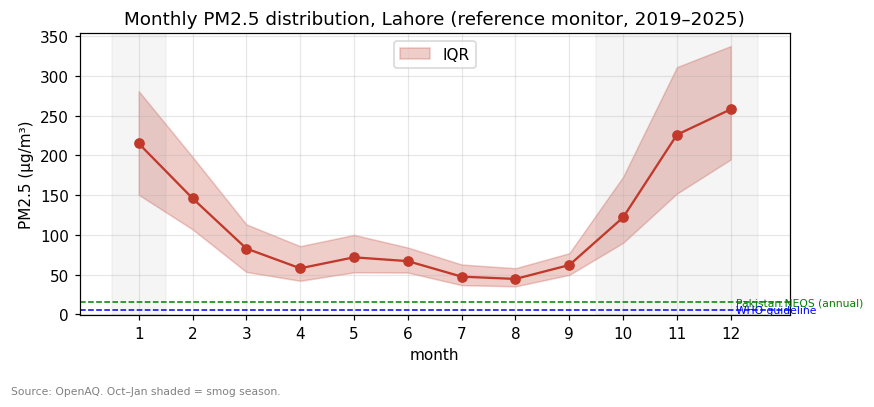

smog-season median: 206.0 | rest: 62.3


In [4]:
m = df.dropna(subset=['pm25']).groupby(df.date.dt.month).pm25.agg(['median', lambda x: x.quantile(.25), lambda x: x.quantile(.75)])
m.columns = ['median','q25','q75']
fig, ax = plt.subplots(figsize=(8,3.5))
ax.plot(m.index, m['median'], 'o-', color='#c0392b')
ax.fill_between(m.index, m.q25, m.q75, alpha=.25, color='#c0392b', label='IQR')
ax.axhline(15, ls='--', lw=1, color='green');  ax.text(12.1, 15, 'Pakistan NEQS (annual)', fontsize=7, color='green', va='center')
ax.axhline(5, ls='--', lw=1, color='blue');    ax.text(12.1, 5, 'WHO guideline', fontsize=7, color='blue', va='center')
ax.set(xticks=range(1,13), xlabel='month', ylabel='PM2.5 (µg/m³)',
       title='Monthly PM2.5 distribution, Lahore (reference monitor, 2019–2025)')
ax.legend()
fig.text(.01,-.04,'Source: OpenAQ. Oct–Jan shaded = smog season.', fontsize=7, color='gray')
ax.axvspan(9.5,12.5,alpha=.08,color='gray'); ax.axvspan(.5,1.5,alpha=.08,color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/eda_seasonal_cycle.png', bbox_inches='tight'); plt.show()
print('smog-season median:', df[df.smog_season==1].pm25.median(), '| rest:', df[df.smog_season==0].pm25.median())

## 4. AOD ↔ PM2.5 — the core relationship

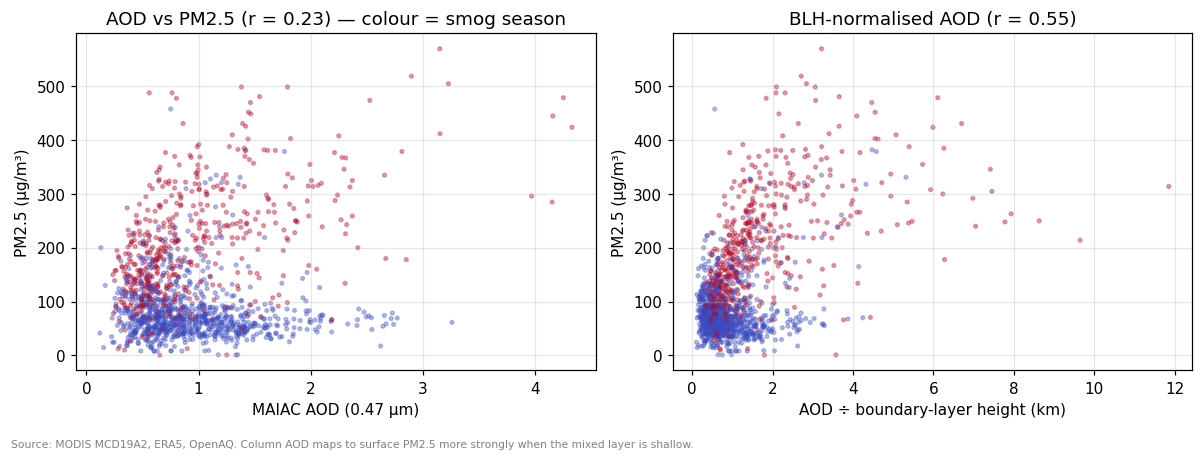

In [5]:
d = df.dropna(subset=['pm25','aod','blh'])
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].scatter(d.aod, d.pm25, s=6, alpha=.35, c=d.smog_season, cmap='coolwarm')
axes[0].set(xlabel='MAIAC AOD (0.47 µm)', ylabel='PM2.5 (µg/m³)',
            title=f'AOD vs PM2.5 (r = {d.aod.corr(d.pm25):.2f}) — colour = smog season')
sc = axes[1].scatter(d.aod_over_blh, d.pm25, s=6, alpha=.35, c=d.smog_season, cmap='coolwarm')
axes[1].set(xlabel='AOD ÷ boundary-layer height (km)', ylabel='PM2.5 (µg/m³)',
            title=f'BLH-normalised AOD (r = {d.aod_over_blh.corr(d.pm25):.2f})')
fig.text(.01,-.03,'Source: MODIS MCD19A2, ERA5, OpenAQ. Column AOD maps to surface PM2.5 more strongly when the mixed layer is shallow.',
         fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/eda_aod_pm25.png', bbox_inches='tight'); plt.show()

## 5. Fires and smog-season PM2.5

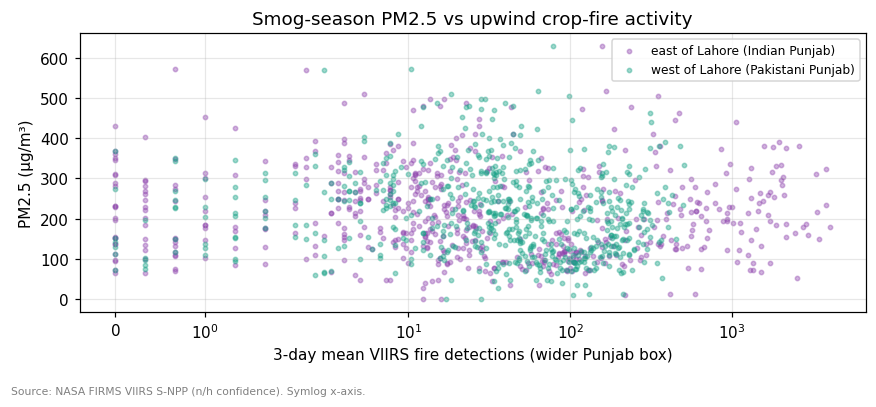

corr (smog season): east_roll3 0.03 | west_roll3 -0.1


In [6]:
d = df.dropna(subset=['pm25'])
smog = d[d.smog_season==1]
fig, ax = plt.subplots(figsize=(8,3.5))
ax.scatter(smog.fires_east_roll3, smog.pm25, s=8, alpha=.4, label='east of Lahore (Indian Punjab)', color='#8e44ad')
ax.scatter(smog.fires_west_roll3, smog.pm25, s=8, alpha=.4, label='west of Lahore (Pakistani Punjab)', color='#16a085')
ax.set(xscale='symlog', xlabel='3-day mean VIIRS fire detections (wider Punjab box)',
       ylabel='PM2.5 (µg/m³)', title='Smog-season PM2.5 vs upwind crop-fire activity')
ax.legend(fontsize=8)
fig.text(.01,-.04,'Source: NASA FIRMS VIIRS S-NPP (n/h confidence). Symlog x-axis.', fontsize=7, color='gray')
plt.tight_layout(); plt.savefig(f'{FIG}/eda_fires.png', bbox_inches='tight'); plt.show()
print('corr (smog season): east_roll3', smog.pm25.corr(smog.fires_east_roll3).round(2),
      '| west_roll3', smog.pm25.corr(smog.fires_west_roll3).round(2))

## 6. Predictor correlation matrix

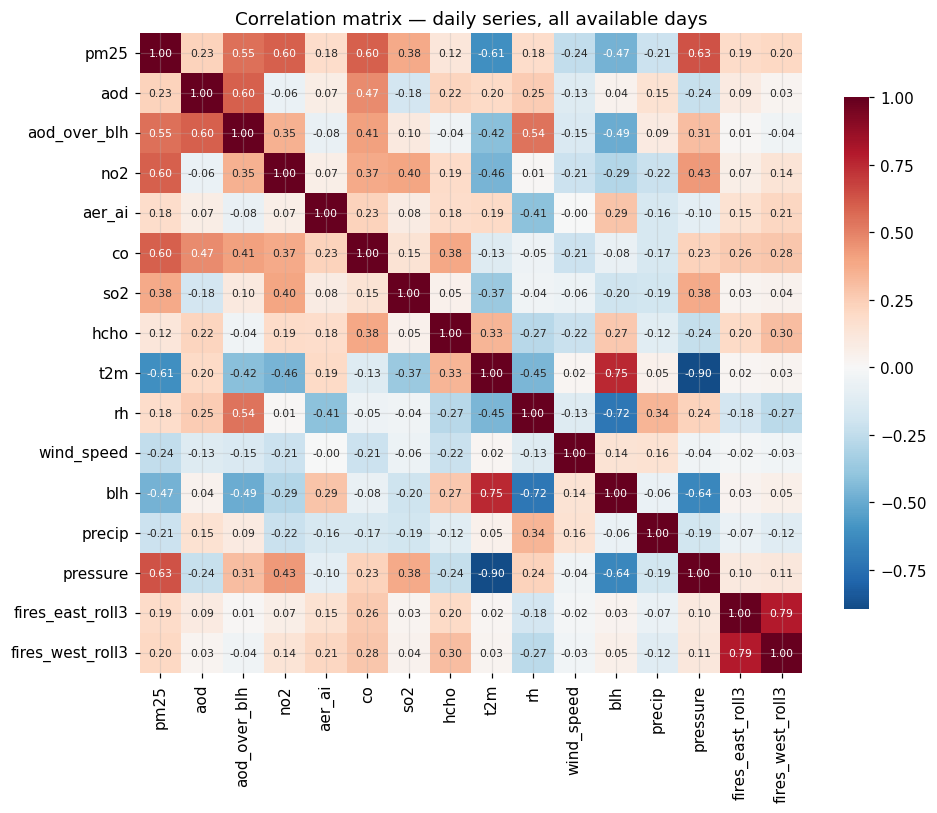

In [7]:
feats = ['pm25','aod','aod_over_blh','no2','aer_ai','co','so2','hcho',
         't2m','rh','wind_speed','blh','precip','pressure',
         'fires_east_roll3','fires_west_roll3']
corr = df[feats].corr()
fig, ax = plt.subplots(figsize=(9,7.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            annot_kws={'size':7}, cbar_kws={'shrink':.8}, ax=ax)
ax.set_title('Correlation matrix — daily series, all available days')
plt.tight_layout(); plt.savefig(f'{FIG}/eda_corr_matrix.png', bbox_inches='tight'); plt.show()

## Takeaways

1. **One reference monitor** with a hard stop in Feb 2025 and ~21% gaps — the
   reconstruction is genuinely useful (it fills those gaps), and the low-cost
   network gives an independent check for the post-Feb-2025 tail.
2. **Strong seasonality**: smog-season median PM2.5 is ~3–4× the summer level;
   every month's median exceeds the WHO guideline by an order of magnitude.
3. **AOD is the workhorse predictor** and BLH-normalising it visibly tightens
   the relationship — the interaction feature earns its place.
4. **Contemporaneous fire counts correlate only weakly with smog-season
   PM2.5** (r ≈ 0.03 east, −0.10 west): within the season PM2.5 is high
   regardless, and transport depends on wind and timing. Fires stay in the
   feature set (with lags), but any "crop-burning share" claim would be
   unsupported — a caveat the write-up keeps.
5. S5P gas columns are 78–94% complete; the model must tolerate missing
   satellite days (tree models handle NaN natively / via imputation flags).